# Parameter study: projectile and counterweight arm lengths

This notebook performs a parameter study of the projectile and counterweight arm lengths of a trebuchet. It fixes the total arm length and varies the fraction projectile_arm_length/total_arm_length. For some values of this fraction, the projectile sling is not in tension for the full duration of the launch.

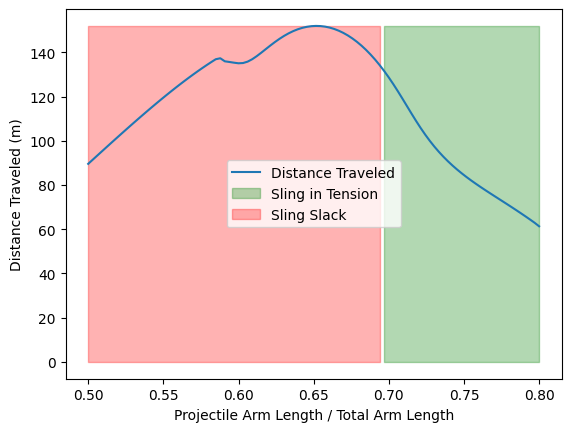

In [1]:
import sys

sys.path.insert(0, "../../src")
from pytrebuchet import Trebuchet, Projectile, Simulation
import numpy as np
import matplotlib.pyplot as plt

# Define range of arm fraction values to test
arm_fractions = np.linspace(
    0.5, 0.8, 100
)  # fraction of total arm length that is projectile arm
total_arm_length = 1.75 + 6.792

# Define result arrays
distances = np.empty_like(arm_fractions, dtype=np.float64)
in_tension = np.empty_like(arm_fractions, dtype=bool)  # Track if sling stays in tension

# Compute distance for each arm fraction
default = Trebuchet.default()
projectile = Projectile.default()
for i, arm_fraction in enumerate(arm_fractions):
    # Create trebuchet with specified arm lengths
    projectile_arm_length = arm_fraction * total_arm_length
    counterweight_arm_length = total_arm_length - projectile_arm_length
    trebuchet = Trebuchet(
        l_weight_arm=counterweight_arm_length,
        l_projectile_arm=projectile_arm_length,
        l_sling_projectile=default.l_sling_projectile,
        l_sling_weight=default.l_sling_weight,
        h_pivot=default.h_pivot,
        mass_arm=default.mass_arm,
        mass_weight=default.mass_weight,
        release_angle=default.release_angle,
    )

    # Simulate
    simulation = Simulation(
        trebuchet, projectile, verify_sling_tension=False
    )  # we will check tension manually
    simulation.solve()

    # Record distance and tension status
    distances[i] = simulation.distance_traveled
    in_tension[i] = np.all(simulation.where_sling_in_tension())

# Plot results
fig, ax = plt.subplots()
ax.plot(arm_fractions, distances, label="Distance Traveled")
ax.fill_between(
    arm_fractions,
    0,
    np.max(distances),
    where=in_tension,
    color="green",
    alpha=0.3,
    label="Sling in Tension",
)
ax.fill_between(
    arm_fractions,
    0,
    np.max(distances),
    where=~in_tension,
    color="red",
    alpha=0.3,
    label="Sling Slack",
)
ax.set_xlabel("Projectile Arm Length / Total Arm Length")
ax.set_ylabel("Distance Traveled (m)")
ax.legend()
plt.show()